## Diagnóstico BR-101 Joinville–Florianópolis e teste da tese ViaMar (2022–2025)

**Projeto:** Diagnóstico de acidentes para o estudo de impacto da ViaMar (Joinville-Florianopolis)

**Autor:** Lucas Handerson

**Janela de análise:** 2022–2025 (4 anos completos). Todo comparativo de crescimento/variação
neste notebook usa o **mesmo ano de início e o mesmo ano de fim** dos dois lados (ex.: frota
2022→2025 comparada com acidentes 2022→2025) — corrige uma limitação da versão anterior, em que
frota e acidentes eram comparados em janelas diferentes (2020→2025 vs 2024→2025).

**Fonte dos dados:** Acidentes PRF (`datatran2022-2025`, agrupados por ocorrência e por
pessoa/veículo); volume de tráfego DNIT PNCT (`vmda2022_snv_202301b`, `contagem_trafego_2020`);
frota SENATRAN (`frota-dezembro2022`, `FrotaporMunicipioetipoDEZEMBRO2025`); população residente
IBGE Censo 2022 (`populacao_corredor`); qualidade do pavimento CNT 2025
(`cnt_pesquisa_rodovias_2025`). Detalhe completo de cada fonte em
[`analysis/readme_fontes.md`](readme_fontes.md).

### Contexto

A futura rodovia **ViaMar** ligará Joinville a Florianópolis, em paralelo ao trecho da **BR-101**
que hoje faz essa ligação (municípios de Garuvá a Palhoça, aproximadamente do km 0 ao km 215 da
BR-101/SC). Este notebook faz duas coisas em sequência:

1. **Diagnóstico da situação atual** (seções 1–4): onde, quando e por que os acidentes acontecem
   no corredor, como ele se compara ao restante da rodovia e do país, e se o padrão se sustenta
   ano a ano — usando os 4 anos completos mais recentes com dado público disponível (2022–2025).
2. **Teste da tese de saturação estrutural x sazonalidade turística** (seções 5–9): cruza os
   mesmos acidentes com volume de tráfego (DNIT), frota de veículos (SENATRAN), perfil horário +
   população residente (Censo 2022), tipo de veículo envolvido e qualidade do pavimento (CNT
   2025) — para checar se a saturação do corredor é estrutural (tráfego, frota, pendularidade) ou
   melhor explicada por turismo de verão.

Roda de forma independente (sem notebook): lê tudo de `../dados` e escreve as figuras em
`../output/figs`.

### Setup

In [1]:
import json
import re
import unicodedata
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

ROOT = Path.cwd().parent
DADOS_DIR = ROOT / "dados"
FIGS_DIR = ROOT / "output" / "figs"
FIGS_DIR.mkdir(parents=True, exist_ok=True)

COR_DESTAQUE = "#c0392b"
COR_BASE = "#2a78d6"
COR_NEUTRA = "#7f8c8d"

ANO_INICIO, ANO_FIM = 2022, 2025
ANOS = list(range(ANO_INICIO, ANO_FIM + 1))
N_ANOS = len(ANOS)

CORREDOR_MUNICIPIOS = [
    "GARUVA", "JOINVILLE", "ARAQUARI", "BARRA VELHA", "BALNEARIO PICARRAS",
    "PENHA", "NAVEGANTES", "ITAJAI", "CAMBORIU", "BALNEARIO CAMBORIU",
    "ITAPEMA", "PORTO BELO", "TIJUCAS", "GOVERNADOR CELSO RAMOS", "BIGUACU",
    "SAO JOSE", "FLORIANOPOLIS", "PALHOCA",
]
MUNICIPIO_LABEL = {
    "GARUVA": "Garuvá", "JOINVILLE": "Joinville", "ARAQUARI": "Araquari",
    "BARRA VELHA": "Barra Velha", "BALNEARIO PICARRAS": "Bal. Piçarras",
    "PENHA": "Penha", "NAVEGANTES": "Navegantes", "ITAJAI": "Itajaí",
    "CAMBORIU": "Camboriú", "BALNEARIO CAMBORIU": "Bal. Camboriú",
    "ITAPEMA": "Itapema", "PORTO BELO": "Porto Belo", "TIJUCAS": "Tijucas",
    "GOVERNADOR CELSO RAMOS": "Gov. Celso Ramos", "BIGUACU": "Biguaçu",
    "SAO JOSE": "São José", "FLORIANOPOLIS": "Florianópolis", "PALHOCA": "Palhoça",
}
MUNICIPIO_IBGE = {
    "ARAQUARI": 4201307, "BALNEARIO CAMBORIU": 4202008, "BARRA VELHA": 4202107,
    "BIGUACU": 4202305, "CAMBORIU": 4203204, "FLORIANOPOLIS": 4205407,
    "GARUVA": 4205803, "GOVERNADOR CELSO RAMOS": 4206009, "ITAJAI": 4208203,
    "ITAPEMA": 4208302, "JOINVILLE": 4209102, "NAVEGANTES": 4211306,
    "PALHOCA": 4211900, "PENHA": 4212502, "BALNEARIO PICARRAS": 4212809,
    "PORTO BELO": 4213500, "SAO JOSE": 4216602, "TIJUCAS": 4218004,
}
CORREDOR_KM_MIN, CORREDOR_KM_MAX = 0, 232
CORREDOR_KM_EXTENSAO = 215
RESTO_KM_EXTENSAO = 463 - CORREDOR_KM_EXTENSAO

# SENATRAN e PRF/IBGE grafam "Balneário Piçarras" de formas diferentes (com/sem "de") --
# sem este alias o município ficava fora dos totais de frota por não bater com CORREDOR_MUNICIPIOS.
MUNICIPIO_ALIASES = {"BALNEARIO DE PICARRAS": "BALNEARIO PICARRAS"}


def strip_accents(s):
    norm = "".join(c for c in unicodedata.normalize("NFD", str(s)) if unicodedata.category(c) != "Mn").upper().strip()
    return MUNICIPIO_ALIASES.get(norm, norm)

## 1 - Acidentes PRF 2022-2025: panorama nacional e recorte do corredor

In [2]:
def carregar_datatran(nome_arquivo, ano):
    df = pd.read_csv(DADOS_DIR / nome_arquivo, sep=";", encoding="latin1", low_memory=False)
    df["data_inversa"] = pd.to_datetime(df["data_inversa"], format="%Y-%m-%d", errors="coerce")
    df["km_num"] = pd.to_numeric(df["km"].astype(str).str.replace(",", ".", regex=False), errors="coerce")
    df["ano"] = ano
    return df


print("=" * 70)
print(f"1 - CARREGANDO ACIDENTES (PRF, {ANO_INICIO}-{ANO_FIM})")
print("=" * 70)

dt = pd.concat([carregar_datatran(f"datatran{a}.csv", a) for a in ANOS], ignore_index=True)

br101_sc = dt[(dt["br"] == 101) & (dt["uf"] == "SC")].copy()
corredor = br101_sc[br101_sc["municipio"].isin(CORREDOR_MUNICIPIOS)].copy()
resto = br101_sc[~br101_sc["municipio"].isin(CORREDOR_MUNICIPIOS)].copy()

# acidentes agrupados por pessoa/veículo -- um arquivo por ano, usado nas seções 4 e 8 (tipo de veículo)
pessoas_por_ano = {}
for a in ANOS:
    p = pd.read_csv(DADOS_DIR / f"acidentes{a}_pessoas.csv", sep=";", encoding="latin1", low_memory=False)
    ids_corredor_ano = corredor.loc[corredor["ano"] == a, "id"]
    pessoas_por_ano[a] = p[p["id"].isin(ids_corredor_ano)].copy()
pessoas_corredor = pd.concat(pessoas_por_ano.values(), ignore_index=True)

br_rank = dt["br"].value_counts().head(10)
br101_uf = (dt[dt["br"] == 101].groupby("uf")
            .agg(acidentes=("id", "count"), mortos=("mortos", "sum"))
            .sort_values("acidentes", ascending=False))
corredor_por_ano = corredor.groupby("ano").size()

print(f"Acidentes no Brasil ({N_ANOS} anos):        {len(dt):>7,}")
print(f"Acidentes na BR-101 (nacional):        {int((dt['br']==101).sum()):>7,}  -> rodovia #{list(br_rank.index).index(101)+1} em acidentes")
print(f"Acidentes na BR-101/SC:                {len(br101_sc):>7,}  -> estado #{list(br101_uf.index).index('SC')+1} dentro da BR-101")
print()
print(f"Acidentes no corredor Joinville-Palhoça ({N_ANOS} anos): {len(corredor):>7,} ({len(corredor)/len(br101_sc)*100:.1f}% da BR-101/SC)")
print(f"Acidentes no restante da BR-101/SC:                 {len(resto):>7,}")
print("Acidentes no corredor por ano (todos completos, sem necessidade de anualizar):")
for ano, n in corredor_por_ano.items():
    print(f"  {ano}: {n:>5,}")
print(f"Densidade corredor:  {len(corredor)/(CORREDOR_KM_EXTENSAO*N_ANOS):.1f} acid./km/ano (média {N_ANOS} anos)")
print(f"Densidade restante:  {len(resto)/(RESTO_KM_EXTENSAO*N_ANOS):.1f} acid./km/ano (média {N_ANOS} anos)")
print(f"Vítimas fatais no corredor: {int(corredor['mortos'].sum())} ({(corredor['mortos']>0).mean()*100:.2f}% dos acidentes)")
print(f"Vítimas fatais no restante: {int(resto['mortos'].sum())} ({(resto['mortos']>0).mean()*100:.2f}% dos acidentes)")

1 - CARREGANDO ACIDENTES (PRF, 2022-2025)


Acidentes no Brasil (4 anos):        278,057
Acidentes na BR-101 (nacional):         48,184  -> rodovia #1 em acidentes
Acidentes na BR-101/SC:                 16,634  -> estado #1 dentro da BR-101

Acidentes no corredor Joinville-Palhoça (4 anos):  12,947 (77.8% da BR-101/SC)
Acidentes no restante da BR-101/SC:                   3,687
Acidentes no corredor por ano (todos completos, sem necessidade de anualizar):
  2022: 3,016
  2023: 3,161
  2024: 3,418
  2025: 3,352
Densidade corredor:  15.1 acid./km/ano (média 4 anos)
Densidade restante:  3.7 acid./km/ano (média 4 anos)
Vítimas fatais no corredor: 377 (2.80% dos acidentes)
Vítimas fatais no restante: 131 (3.47% dos acidentes)


### 1.1 - Panorama nacional: por que a BR-101/SC é o ponto certo para olhar

A BR-101 é, isoladamente, a rodovia federal com mais acidentes registrados no país no período
2022-2025 — e Santa Catarina é o estado que mais concentra ocorrências dentro dela.

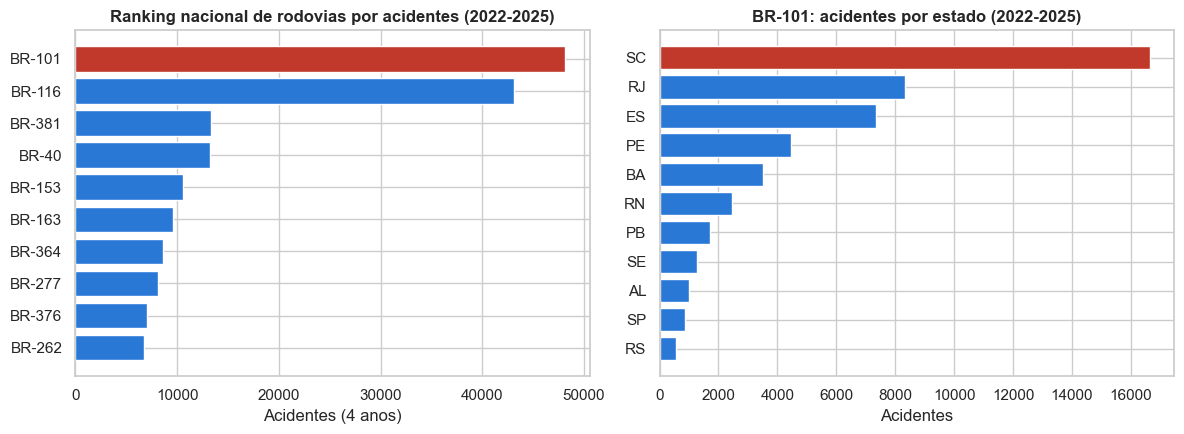

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

labels = [f"BR-{int(b)}" for b in br_rank.index]
cores = [COR_DESTAQUE if b == "BR-101" else COR_BASE for b in labels]
axes[0].barh(labels[::-1], br_rank.values[::-1], color=cores[::-1])
axes[0].set_title(f"Ranking nacional de rodovias por acidentes ({ANO_INICIO}-{ANO_FIM})", weight="bold")
axes[0].set_xlabel(f"Acidentes ({N_ANOS} anos)")

cores_uf = [COR_DESTAQUE if uf == "SC" else COR_BASE for uf in br101_uf.index]
axes[1].barh(br101_uf.index[::-1], br101_uf["acidentes"].values[::-1], color=cores_uf[::-1])
axes[1].set_title(f"BR-101: acidentes por estado ({ANO_INICIO}-{ANO_FIM})", weight="bold")
axes[1].set_xlabel("Acidentes")

plt.tight_layout()
plt.savefig(FIGS_DIR / "fig0a_panorama_nacional.png", dpi=150)
plt.show()

### 1.2 - O corredor Joinville-Florianópolis concentra o problema dentro do próprio SC

Definindo o corredor como os municípios de Garuvá a Palhoça (km 0 a ~215 da BR-101/SC).

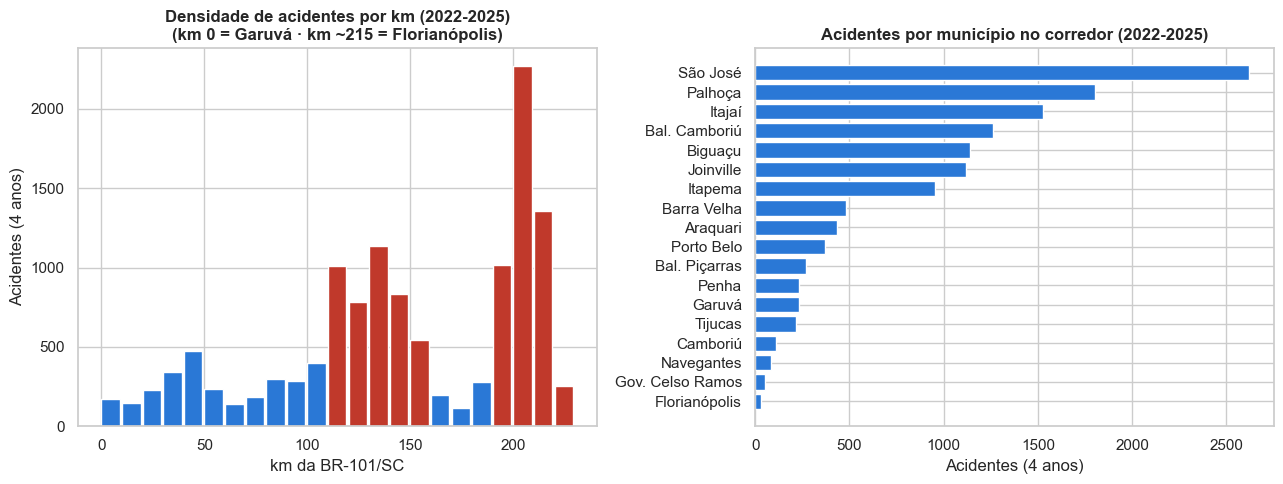

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bins = list(range(0, 231, 10))
km_counts = corredor["km_num"].dropna().groupby(pd.cut(corredor["km_num"].dropna(), bins=bins)).size()
hotspot = [(iv.left >= 190) or (110 <= iv.left < 160) for iv in km_counts.index]
cores_km = [COR_DESTAQUE if h else COR_BASE for h in hotspot]
axes[0].bar([iv.left for iv in km_counts.index], km_counts.values, width=9, color=cores_km, align="edge")
axes[0].set_title(f"Densidade de acidentes por km ({ANO_INICIO}-{ANO_FIM})\n(km 0 = Garuvá · km ~215 = Florianópolis)", weight="bold")
axes[0].set_xlabel("km da BR-101/SC")
axes[0].set_ylabel(f"Acidentes ({N_ANOS} anos)")

sev_municipio = (corredor.groupby("municipio")["id"].count()
                  .rename(index=MUNICIPIO_LABEL).sort_values())
axes[1].barh(sev_municipio.index, sev_municipio.values, color=COR_BASE)
axes[1].set_title(f"Acidentes por município no corredor ({ANO_INICIO}-{ANO_FIM})", weight="bold")
axes[1].set_xlabel(f"Acidentes ({N_ANOS} anos)")

plt.tight_layout()
plt.savefig(FIGS_DIR / "fig0b_corredor_km_municipios.png", dpi=150)
plt.show()

### 1.3 - O padrão se sustenta ao longo do tempo

Com 2022-2025 sendo 4 anos **completos**, o comparativo por ano não precisa de nenhuma
anualização (diferente da versão anterior, que tinha 2026 parcial) -- cada barra já é
diretamente comparável às demais.

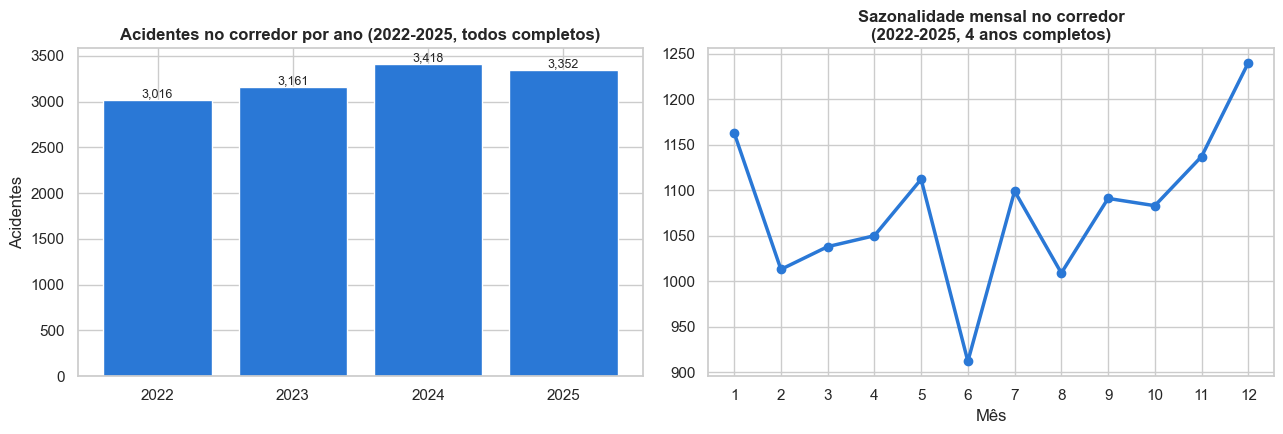

Acidentes no corredor: 3,016 (2022) -> 3,352 (2025), +11.1%
Sazonalidade: pico 12 (1,240) vs vale 6 (912) -- diferença de 36%


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

anos_lbl = corredor_por_ano.index.tolist()
valores = corredor_por_ano.values.tolist()
axes[0].bar([str(a) for a in anos_lbl], valores, color=COR_BASE)
axes[0].set_title(f"Acidentes no corredor por ano ({ANO_INICIO}-{ANO_FIM}, todos completos)", weight="bold")
axes[0].set_ylabel("Acidentes")
for i, v in enumerate(valores):
    axes[0].text(i, v + 30, f"{v:,}", ha="center", fontsize=9)

sazonalidade = corredor.groupby(corredor["data_inversa"].dt.month).size()
axes[1].plot(sazonalidade.index, sazonalidade.values, color=COR_BASE, lw=2.5, marker="o")
axes[1].set_title(f"Sazonalidade mensal no corredor\n({ANO_INICIO}-{ANO_FIM}, {N_ANOS} anos completos)", weight="bold")
axes[1].set_xlabel("Mês")
axes[1].set_xticks(range(1, 13))

plt.tight_layout()
plt.savefig(FIGS_DIR / "fig0c_ano_sazonalidade.png", dpi=150)
plt.show()

crescimento_acid_total = (corredor_por_ano[ANO_FIM] / corredor_por_ano[ANO_INICIO] - 1) * 100
pico_vale_pct = (sazonalidade.max() - sazonalidade.min()) / sazonalidade.min() * 100
print(f"Acidentes no corredor: {corredor_por_ano[ANO_INICIO]:,} ({ANO_INICIO}) -> {corredor_por_ano[ANO_FIM]:,} ({ANO_FIM}), {crescimento_acid_total:+.1f}%")
print(f"Sazonalidade: pico {sazonalidade.idxmax()} ({sazonalidade.max():,}) vs vale {sazonalidade.idxmin()} ({sazonalidade.min():,}) -- diferença de {pico_vale_pct:.0f}%")

### 1.4 - Quando e por que os acidentes acontecem

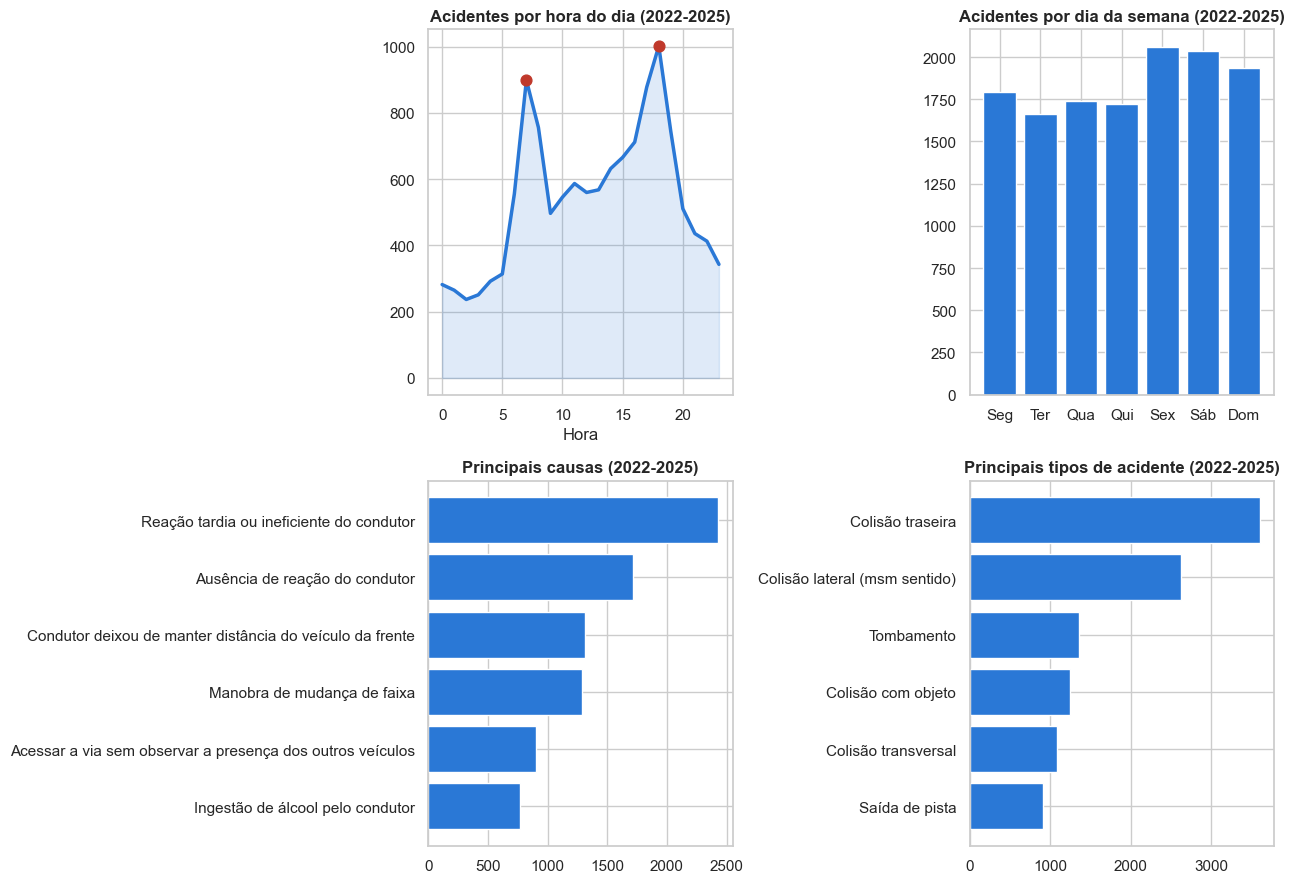

Acidentes em horário de pico (7-8h, 17-19h): 33.1% do total
Tipo de pista:
tipo_pista
Dupla       53.9
Múltipla    36.6
Simples      9.5
Name: proportion, dtype: float64


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

hora = pd.to_datetime(corredor["horario"], format="%H:%M:%S", errors="coerce").dt.hour
hora_counts = hora.value_counts().sort_index()
axes[0, 0].plot(hora_counts.index, hora_counts.values, color=COR_BASE, lw=2.5)
axes[0, 0].fill_between(hora_counts.index, hora_counts.values, color=COR_BASE, alpha=0.15)
for h in (7, 18):
    axes[0, 0].scatter([h], [hora_counts[h]], color=COR_DESTAQUE, zorder=5, s=60)
axes[0, 0].set_title(f"Acidentes por hora do dia ({ANO_INICIO}-{ANO_FIM})", weight="bold")
axes[0, 0].set_xlabel("Hora")

DIA_LABEL = {"segunda-feira": "Seg", "terça-feira": "Ter", "quarta-feira": "Qua",
             "quinta-feira": "Qui", "sexta-feira": "Sex", "sábado": "Sáb", "domingo": "Dom"}
dia_counts = corredor["dia_semana"].value_counts()
dia_out = pd.Series({label: dia_counts.get(d, 0) for d, label in DIA_LABEL.items()})
axes[0, 1].bar(dia_out.index, dia_out.values, color=COR_BASE)
axes[0, 1].set_title(f"Acidentes por dia da semana ({ANO_INICIO}-{ANO_FIM})", weight="bold")

CAUSA_LABEL = {"Trafegar com motocicleta (ou similar) entre as faixas": "Moto entre faixas"}
causa_counts = corredor["causa_acidente"].value_counts().head(6).rename(index=CAUSA_LABEL)
axes[1, 0].barh(causa_counts.index[::-1], causa_counts.values[::-1], color=COR_BASE)
axes[1, 0].set_title(f"Principais causas ({ANO_INICIO}-{ANO_FIM})", weight="bold")

TIPO_LABEL = {"Colisão lateral mesmo sentido": "Colisão lateral (msm sentido)",
              "Saída de leito carroçável": "Saída de pista"}
tipo_counts = corredor["tipo_acidente"].value_counts().head(6).rename(index=TIPO_LABEL)
axes[1, 1].barh(tipo_counts.index[::-1], tipo_counts.values[::-1], color=COR_BASE)
axes[1, 1].set_title(f"Principais tipos de acidente ({ANO_INICIO}-{ANO_FIM})", weight="bold")

plt.tight_layout()
plt.savefig(FIGS_DIR / "fig0d_hora_dia_causa_tipo.png", dpi=150)
plt.show()

pct_pico_geral = hora.isin([7, 8, 17, 18, 19]).mean() * 100
tipo_pista = corredor["tipo_pista"].value_counts(normalize=True) * 100
print(f"Acidentes em horário de pico (7-8h, 17-19h): {pct_pico_geral:.1f}% do total")
print("Tipo de pista:")
print(tipo_pista.round(1))

## 2 - Volume de tráfego (DNIT VMDa 2022) x densidade de acidentes por trecho

**Nota sobre a janela de dados:** o DNIT não publicou VMD/VMDa para o corredor após dezembro de
2022 (confirmado no portal de dados abertos do DNIT em jul/2026) -- não existe um segundo ponto
dentro de 2022-2025 para calcular crescimento de tráfego pareado com os acidentes. Por isso esta
seção usa o VMDa 2022 como **snapshot único** (o ano em que a janela começa), correlacionado com
a densidade de acidentes de 2022-2025 -- sem misturar um comparativo de crescimento com pontas
fora da janela (o notebook anterior comparava 2020 vs 2022, o que já não fazíamos para os demais
comparativos). O Nível de Serviço (NS) do DNIT abaixo é de dezembro/2020, a única fonte
disponível para esse indicador -- mantido apenas como contexto de engenharia rotulado
explicitamente como anterior à janela, não como parte de um comparativo pareado.

2 - VOLUME DE TRÁFEGO (DNIT VMDa 2022) x DENSIDADE DE ACIDENTES POR TRECHO


Trechos com VMD válido no corredor -- Dez/2022: 27
Correlação VMDa 2022 x densidade de acidentes 2022-2025 (por trecho, corredor): r = 0.22
VMDa médio corredor -- Dez/2022: 42,261 veíc/dia (snapshot único, sem par para calcular crescimento dentro de 2022-2025)
[contexto pré-janela, Dez/2020] Trechos com Nível de Serviço D (próximo da capacidade): 8 de 30


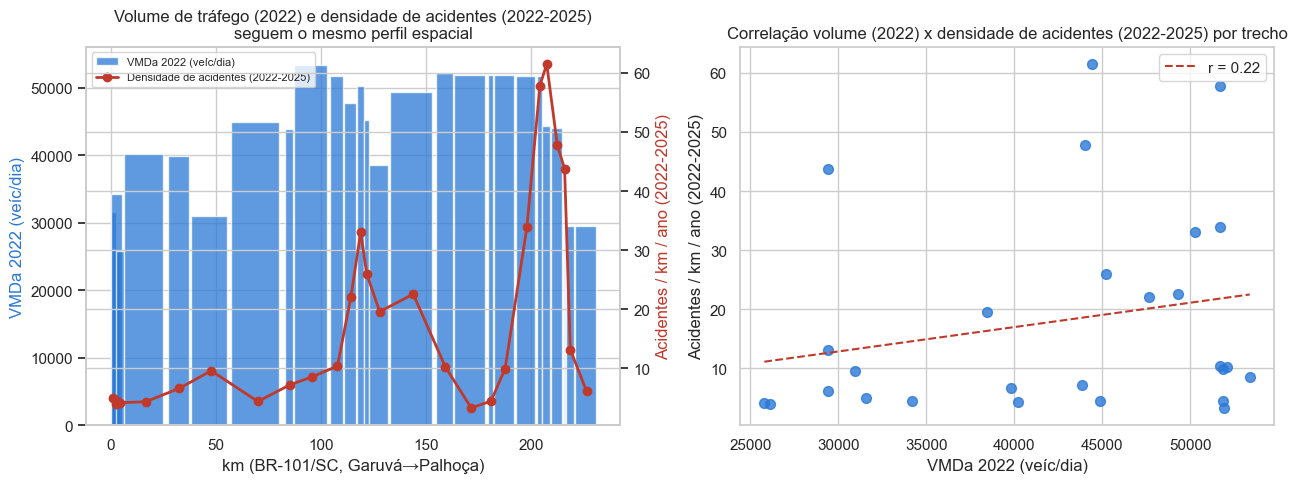

In [7]:
print("=" * 70)
print("2 - VOLUME DE TRÁFEGO (DNIT VMDa 2022) x DENSIDADE DE ACIDENTES POR TRECHO")
print("=" * 70)


def carregar_vmd_com_km(caminho, sheet_name=None):
    if sheet_name:
        df = pd.read_excel(caminho, sheet_name=sheet_name)
    else:
        df = pd.read_csv(caminho, sep=None, engine="python")
    sub = df[(df["vl_br"] == 101) & (df["sg_uf"] == "SC")].copy()

    def to_num(col):
        return pd.to_numeric(sub[col].astype(str).str.replace(",", ".", regex=False), errors="coerce")

    sub["vl_km_inic"] = to_num("vl_km_inic")
    sub["vl_km_fina"] = to_num("vl_km_fina")
    sub = sub.dropna(subset=["vl_km_inic", "vl_km_fina"])
    sub = sub[sub["vl_km_inic"] < CORREDOR_KM_MAX]
    for c in ("VMDa_C", "VMDa_D"):
        sub[c] = to_num(c)
    sub["vmda_total"] = sub["VMDa_C"].fillna(0) + sub["VMDa_D"].fillna(0)
    # vários registros podem cobrir o mesmo trecho (ex.: "Referencial" duplicado) -> agrega por km
    agg = (sub[sub["vmda_total"] > 0]
           .groupby(["vl_km_inic", "vl_km_fina"], as_index=False)
           .agg(vmda_total=("vmda_total", "mean"), ds_local_i=("ds_local_i", "first")))
    return agg.sort_values("vl_km_inic")


vmd_2022 = carregar_vmd_com_km(DADOS_DIR / "vmda2022_snv_202301b.xlsx", sheet_name="SNV202301B")
print(f"Trechos com VMD válido no corredor -- Dez/2022: {len(vmd_2022)}")

# acidentes por trecho: para cada segmento VMD, conta acidentes do corredor (2022-2025) cujo km cai no intervalo
acid_por_km = corredor["km_num"].dropna()


def acidentes_no_trecho(km_i, km_f, serie_km):
    return int(((serie_km >= km_i) & (serie_km < km_f)).sum())


vmd_2022["extensao"] = (vmd_2022["vl_km_fina"] - vmd_2022["vl_km_inic"]).clip(lower=0.1)
vmd_2022["acidentes_periodo"] = [
    acidentes_no_trecho(i, f, acid_por_km) for i, f in zip(vmd_2022["vl_km_inic"], vmd_2022["vl_km_fina"])
]
vmd_2022["acidentes_por_km_ano"] = vmd_2022["acidentes_periodo"] / vmd_2022["extensao"] / N_ANOS

corr_vmd_acid = vmd_2022[["vmda_total", "acidentes_por_km_ano"]].corr().iloc[0, 1]
print(f"Correlação VMDa 2022 x densidade de acidentes {ANO_INICIO}-{ANO_FIM} (por trecho, corredor): r = {corr_vmd_acid:.2f}")

vmd_2022_media = vmd_2022["vmda_total"].mean()
print(f"VMDa médio corredor -- Dez/2022: {vmd_2022_media:,.0f} veíc/dia (snapshot único, sem par para calcular crescimento dentro de 2022-2025)")

# nível de serviço (LOS) só existe em Dez/2020 -- fora da janela 2022-2025, mantido só como contexto rotulado
ns_2020 = pd.read_csv(DADOS_DIR / "contagem_trafego_2020.csv", sep=None, engine="python")
ns_2020 = ns_2020[(ns_2020["vl_br"] == 101) & (ns_2020["sg_uf"] == "SC")].copy()
ns_2020["vl_km_inic"] = pd.to_numeric(ns_2020["vl_km_inic"].astype(str).str.replace(",", "."), errors="coerce")
ns_2020["vl_km_fina"] = pd.to_numeric(ns_2020["vl_km_fina"].astype(str).str.replace(",", "."), errors="coerce")
ns_2020 = ns_2020.dropna(subset=["vl_km_inic", "NS_C"])
ns_2020 = ns_2020[ns_2020["vl_km_inic"] < CORREDOR_KM_MAX]
trechos_d_ou_pior = ns_2020[ns_2020["NS_C"].isin(["D", "E", "F"]) | ns_2020["NS_D"].isin(["D", "E", "F"])]
print(f"[contexto pré-janela, Dez/2020] Trechos com Nível de Serviço D (próximo da capacidade): {len(trechos_d_ou_pior)} de {len(ns_2020)}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.bar(vmd_2022["vl_km_inic"], vmd_2022["vmda_total"], width=(vmd_2022["extensao"]) * 0.9,
       align="edge", color=COR_BASE, alpha=0.75, label="VMDa 2022 (veíc/dia)")
ax2 = ax.twinx()
ax2.plot(vmd_2022["vl_km_inic"] + vmd_2022["extensao"] / 2, vmd_2022["acidentes_por_km_ano"],
          color=COR_DESTAQUE, marker="o", lw=2, label=f"Densidade de acidentes ({ANO_INICIO}-{ANO_FIM})")
ax.set_xlabel("km (BR-101/SC, Garuvá→Palhoça)")
ax.set_ylabel("VMDa 2022 (veíc/dia)", color=COR_BASE)
ax2.set_ylabel(f"Acidentes / km / ano ({ANO_INICIO}-{ANO_FIM})", color=COR_DESTAQUE)
ax.set_title("Volume de tráfego (2022) e densidade de acidentes (2022-2025)\nseguem o mesmo perfil espacial")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=8)

ax = axes[1]
ax.scatter(vmd_2022["vmda_total"], vmd_2022["acidentes_por_km_ano"], color=COR_BASE, s=50, alpha=0.8)
if len(vmd_2022) > 2:
    z = np.polyfit(vmd_2022["vmda_total"], vmd_2022["acidentes_por_km_ano"], 1)
    xs = np.linspace(vmd_2022["vmda_total"].min(), vmd_2022["vmda_total"].max(), 50)
    ax.plot(xs, np.polyval(z, xs), color=COR_DESTAQUE, ls="--", label=f"r = {corr_vmd_acid:.2f}")
ax.set_xlabel("VMDa 2022 (veíc/dia)")
ax.set_ylabel(f"Acidentes / km / ano ({ANO_INICIO}-{ANO_FIM})")
ax.set_title("Correlação volume (2022) x densidade de acidentes (2022-2025) por trecho")
ax.legend()

plt.tight_layout()
plt.savefig(FIGS_DIR / "fig1_vmd_x_acidentes_2022_2025.png", dpi=150)
plt.show()

## 3 - Frota de veículos (SENATRAN 2022 vs 2025) x crescimento de acidentes

**Correção de janela:** a versão anterior comparava frota 2020→2025 (5 anos) com acidentes
2024→2025 (1 ano) -- janelas diferentes que misturavam efeitos de períodos distintos. Com o
snapshot de frota de dezembro/2022 baixado para esta análise, o comparativo agora usa
**2022→2025 dos dois lados**.


3 - CRESCIMENTO DA FROTA (SENATRAN, 2022 -> 2025) x ACIDENTES NO CORREDOR


C:\Users\Lucas\AppData\Local\Programs\Python\Python312\Lib\site-packages\openpyxl\worksheet\header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


Frota corredor -- Dez/2022: 1,910,799 | Dez/2025: 2,191,311 (+14.7% em 3 anos)
Acidentes corredor -- 2022: 3,016 | 2025: 3,352 (+11.1% em 3 anos)
(mesma janela 2022->2025 dos dois lados -- frota e acidentes agora são diretamente comparáveis)


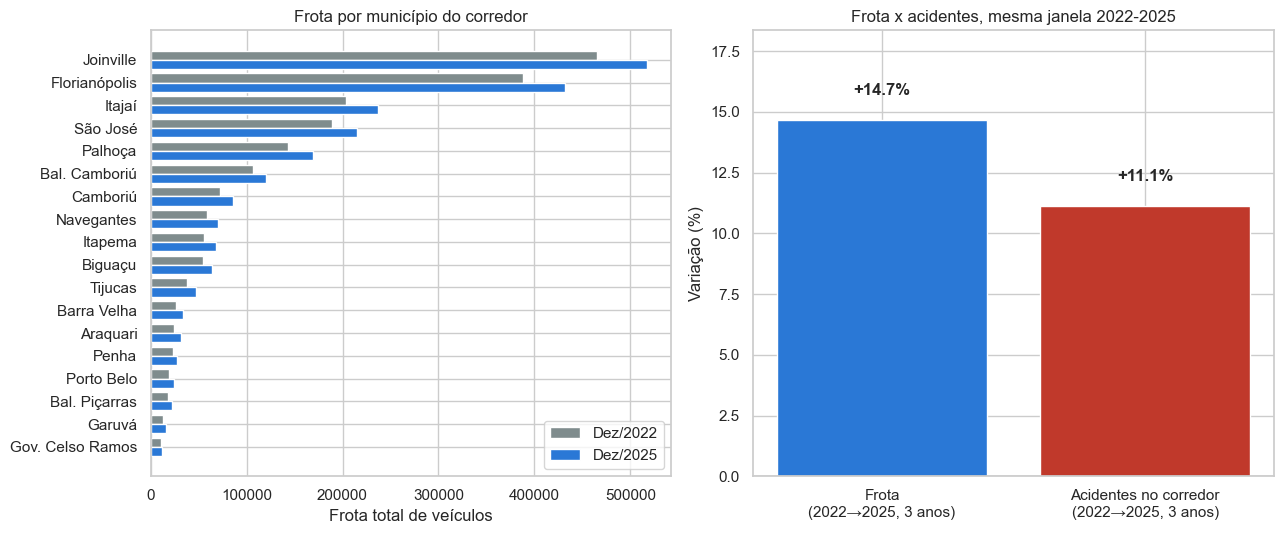

In [8]:
print("\n" + "=" * 70)
print(f"3 - CRESCIMENTO DA FROTA (SENATRAN, {ANO_INICIO} -> {ANO_FIM}) x ACIDENTES NO CORREDOR")
print("=" * 70)


def carregar_frota_wide(caminho, sheet_name):
    """Formato 'largo' (2020, 2025): 1 linha por município, coluna TOTAL já soma todos os tipos."""
    df = pd.read_excel(caminho, sheet_name=sheet_name, skiprows=2)
    df.columns = [str(c).strip().upper() for c in df.columns]
    df["UF"] = df["UF"].astype(str).str.strip()
    df["MUNICIPIO_NORM"] = df["MUNICIPIO"].apply(strip_accents)
    sub = df[(df["UF"] == "SC") & (df["MUNICIPIO_NORM"].isin(CORREDOR_MUNICIPIOS))]
    return sub.groupby("MUNICIPIO_NORM")["TOTAL"].sum()


def carregar_frota_longo(caminho, sheet_name):
    """Formato 'longo' (2022): 1 linha por UF/município/tipo/espécie/eixos -- precisa agregar."""
    df = pd.read_excel(caminho, sheet_name=sheet_name)
    col_uf, col_municipio, col_qtd = df.columns[0], df.columns[1], df.columns[-1]
    df["MUNICIPIO_NORM"] = df[col_municipio].apply(strip_accents)
    sub = df[(df[col_uf].astype(str).str.strip().str.upper() == "SANTA CATARINA")
             & (df["MUNICIPIO_NORM"].isin(CORREDOR_MUNICIPIOS))]
    return sub.groupby("MUNICIPIO_NORM")[col_qtd].sum()


frota_inicio = carregar_frota_longo(DADOS_DIR / "frota-dezembro2022.xlsx", "Layout_G")
frota_fim = carregar_frota_wide(DADOS_DIR / "FrotaporMunicipioetipoDEZEMBRO2025.xlsx", "DEZEMBRO_2025")

frota_inicio_total = frota_inicio.sum()
frota_fim_total = frota_fim.sum()
crescimento_frota = (frota_fim_total / frota_inicio_total - 1) * 100
print(f"Frota corredor -- Dez/{ANO_INICIO}: {frota_inicio_total:,.0f} | Dez/{ANO_FIM}: {frota_fim_total:,.0f} "
      f"({crescimento_frota:+.1f}% em {ANO_FIM - ANO_INICIO} anos)")

acid_inicio = int(corredor_por_ano[ANO_INICIO])
acid_fim = int(corredor_por_ano[ANO_FIM])
crescimento_acid = (acid_fim / acid_inicio - 1) * 100
print(f"Acidentes corredor -- {ANO_INICIO}: {acid_inicio:,} | {ANO_FIM}: {acid_fim:,} ({crescimento_acid:+.1f}% em {ANO_FIM - ANO_INICIO} anos)")
print(f"(mesma janela {ANO_INICIO}->{ANO_FIM} dos dois lados -- frota e acidentes agora são diretamente comparáveis)")

frota_por_mun = (frota_fim.rename(str(ANO_FIM)).to_frame()
                  .join(frota_inicio.rename(str(ANO_INICIO))))
frota_por_mun["crescimento_pct"] = (frota_por_mun[str(ANO_FIM)] / frota_por_mun[str(ANO_INICIO)] - 1) * 100
frota_por_mun = frota_por_mun.rename(index=MUNICIPIO_LABEL).sort_values(str(ANO_FIM), ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

ax = axes[0]
y = np.arange(len(frota_por_mun))
ax.barh(y - 0.2, frota_por_mun[str(ANO_INICIO)], height=0.4, color=COR_NEUTRA, label=f"Dez/{ANO_INICIO}")
ax.barh(y + 0.2, frota_por_mun[str(ANO_FIM)], height=0.4, color=COR_BASE, label=f"Dez/{ANO_FIM}")
ax.set_yticks(y)
ax.set_yticklabels(frota_por_mun.index)
ax.invert_yaxis()
ax.set_xlabel("Frota total de veículos")
ax.set_title("Frota por município do corredor")
ax.legend()

ax = axes[1]
categorias = [f"Frota\n({ANO_INICIO}→{ANO_FIM}, {ANO_FIM-ANO_INICIO} anos)", f"Acidentes no corredor\n({ANO_INICIO}→{ANO_FIM}, {ANO_FIM-ANO_INICIO} anos)"]
valores = [crescimento_frota, crescimento_acid]
cores = [COR_BASE, COR_DESTAQUE]
barras = ax.bar(categorias, valores, color=cores)
ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("Variação (%)")
ax.set_title(f"Frota x acidentes, mesma janela {ANO_INICIO}-{ANO_FIM}")
ax.set_ylim(top=max(valores) * 1.25)
for b, v in zip(barras, valores):
    ax.text(b.get_x() + b.get_width() / 2, v + (1 if v >= 0 else -2), f"{v:+.1f}%", ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig(FIGS_DIR / "fig2_frota_x_acidentes_2022_2025.png", dpi=150)
plt.show()

## 4 - Perfil horário de pico (pendularidade) + população residente 2022

O Censo é uma fotografia única (2022) -- não há um segundo ponto no tempo para comparar
crescimento populacional dentro da janela 2022-2025, então esta seção reporta o nível, não uma
variação.


4 - PERFIL HORÁRIO DE PICO (PROXY DE PENDULARIDADE) + POPULAÇÃO 2022
Acidentes em horário de pico (7-8h, 17-19h): 33.1% do total do corredor (2022-2025)
(5 das 24 horas do dia = 20,8% do tempo; 33.1% dos acidentes em 20.8% do tempo indica concentração pendular, não só lazer)
População residente 2022 no corredor (18 municípios, Censo IBGE): 2,658,004 habitantes


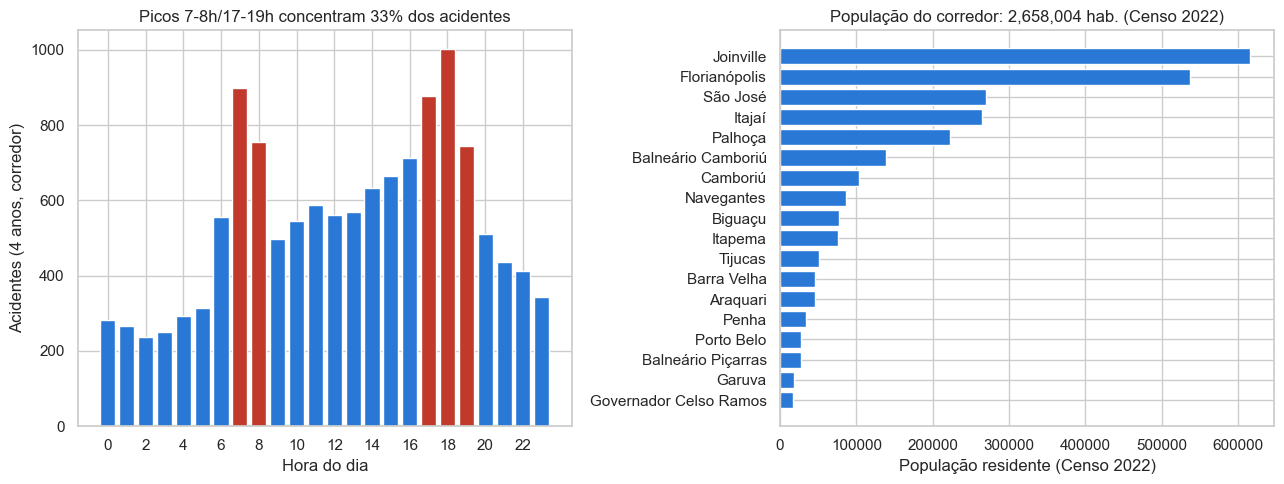

In [9]:
print("\n" + "=" * 70)
print("4 - PERFIL HORÁRIO DE PICO (PROXY DE PENDULARIDADE) + POPULAÇÃO 2022")
print("=" * 70)

hora = pd.to_datetime(corredor["horario"], format="%H:%M:%S", errors="coerce").dt.hour
hora_counts = hora.value_counts().sort_index()
pico = hora.isin([7, 8, 17, 18, 19])
pct_pico = pico.mean() * 100
print(f"Acidentes em horário de pico (7-8h, 17-19h): {pct_pico:.1f}% do total do corredor ({ANO_INICIO}-{ANO_FIM})")
print("(5 das 24 horas do dia = 20,8% do tempo; {:.1f}% dos acidentes em {:.1f}% do tempo "
      "indica concentração pendular, não só lazer)".format(pct_pico, 5 / 24 * 100))

pop_path = DADOS_DIR / "populacao_corredor.json"
pop_corredor = None
if pop_path.exists():
    raw = json.load(open(pop_path, encoding="utf-8"))[1:]
    pop_corredor = pd.DataFrame(raw)
    pop_corredor["municipio"] = pop_corredor["D1N"].str.replace(r"\s*\(SC\)", "", regex=True)
    pop_corredor["populacao"] = pd.to_numeric(pop_corredor["V"], errors="coerce")
    pop_total = pop_corredor["populacao"].sum()
    print(f"População residente 2022 no corredor (18 municípios, Censo IBGE): {pop_total:,.0f} habitantes")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
cores_hora = [COR_DESTAQUE if h in [7, 8, 17, 18, 19] else COR_BASE for h in hora_counts.index]
ax.bar(hora_counts.index, hora_counts.values, color=cores_hora)
ax.set_xlabel("Hora do dia")
ax.set_ylabel(f"Acidentes ({N_ANOS} anos, corredor)")
ax.set_title(f"Picos 7-8h/17-19h concentram {pct_pico:.0f}% dos acidentes")
ax.set_xticks(range(0, 24, 2))

ax = axes[1]
if pop_corredor is not None:
    pc = pop_corredor.sort_values("populacao", ascending=False)
    ax.barh(pc["municipio"], pc["populacao"], color=COR_BASE)
    ax.invert_yaxis()
    ax.set_xlabel("População residente (Censo 2022)")
    ax.set_title(f"População do corredor: {pop_total:,.0f} hab. (Censo 2022)")
else:
    ax.text(0.5, 0.5, "Dados de população não encontrados\n(dados/populacao_corredor.json)",
            ha="center", va="center")

plt.tight_layout()
plt.savefig(FIGS_DIR / "fig3_hora_pico_populacao_2022_2025.png", dpi=150)
plt.show()

## 5 - Tipo de veículo envolvido (proxy de tráfego de carga) -- 2022-2025

**Correção de janela:** a versão anterior só tinha o detalhamento por veículo para jan-mai/2026
(único ano com esse arquivo baixado), fora da janela de 2022-2025 e cobrindo só baixa temporada.
Agora os 4 anos completos têm o mesmo detalhamento (arquivos "agrupados por pessoa" da PRF), o
que permite ver a evolução ano a ano em vez de só a sazonalidade de um ano parcial.


5 - TIPO DE VEÍCULO ENVOLVIDO NO CORREDOR (proxy de tráfego de carga, 2022-2025)
Veículos tipo caminhão/reboque em acidentes do corredor (2022-2025): 14.7%
Top tipos de veículo:
tipo_veiculo
Automóvel          11663
Motocicleta         7597
Motoneta            1794
Caminhonete         1718
Semireboque         1490
Caminhão-trator     1454
Caminhão            1435
Camioneta           1062


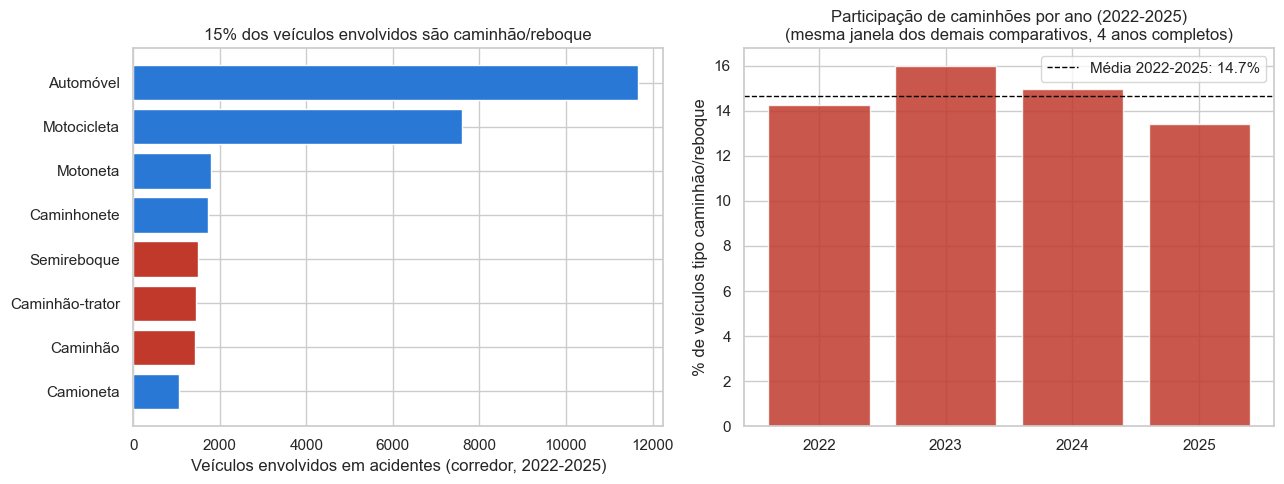


Contexto qualitativo (não auditável, sem série ANTAQ bruta -- ver readme_fontes.md):
  Portos catarinenses: São Francisco do Sul ~4,2 Mt/ano, Itapoá ~4,0 Mt/ano, Portonave ~2,5 Mt/ano,
  Imbituba ~1,7 Mt/ano, Itajaí ~0,9 Mt/ano (números de imprensa ANTAQ/SPAF-SC, não baixados como dado bruto).


In [10]:
print("\n" + "=" * 70)
print(f"5 - TIPO DE VEÍCULO ENVOLVIDO NO CORREDOR (proxy de tráfego de carga, {ANO_INICIO}-{ANO_FIM})")
print("=" * 70)

CAMINHAO_TIPOS = {"Caminhão", "Caminhão-trator", "Caminhão-tanque", "Reboque", "Semireboque"}
tipo_counts = pessoas_corredor["tipo_veiculo"].value_counts()
pct_caminhao = pessoas_corredor["tipo_veiculo"].isin(CAMINHAO_TIPOS).mean() * 100
print(f"Veículos tipo caminhão/reboque em acidentes do corredor ({ANO_INICIO}-{ANO_FIM}): {pct_caminhao:.1f}%")
print("Top tipos de veículo:")
print(tipo_counts.head(8).to_string())

pct_caminhao_por_ano = pd.Series({
    a: pessoas_por_ano[a]["tipo_veiculo"].isin(CAMINHAO_TIPOS).mean() * 100 for a in ANOS
})

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
top = tipo_counts.head(8)
cores_tipo = [COR_DESTAQUE if t in CAMINHAO_TIPOS else COR_BASE for t in top.index]
ax.barh(top.index[::-1], top.values[::-1], color=cores_tipo[::-1])
ax.set_xlabel(f"Veículos envolvidos em acidentes (corredor, {ANO_INICIO}-{ANO_FIM})")
ax.set_title(f"{pct_caminhao:.0f}% dos veículos envolvidos são caminhão/reboque")

ax = axes[1]
ax.bar([str(a) for a in ANOS], pct_caminhao_por_ano.values, color=COR_DESTAQUE, alpha=0.85)
ax.axhline(pct_caminhao, color="black", ls="--", lw=1, label=f"Média {ANO_INICIO}-{ANO_FIM}: {pct_caminhao:.1f}%")
ax.set_ylabel("% de veículos tipo caminhão/reboque")
ax.set_title(f"Participação de caminhões por ano ({ANO_INICIO}-{ANO_FIM})\n(mesma janela dos demais comparativos, 4 anos completos)")
ax.legend()

plt.tight_layout()
plt.savefig(FIGS_DIR / "fig4_tipo_veiculo_2022_2025.png", dpi=150)
plt.show()

print("\nContexto qualitativo (não auditável, sem série ANTAQ bruta -- ver readme_fontes.md):")
print("  Portos catarinenses: São Francisco do Sul ~4,2 Mt/ano, Itapoá ~4,0 Mt/ano, Portonave ~2,5 Mt/ano,")
print("  Imbituba ~1,7 Mt/ano, Itajaí ~0,9 Mt/ano (números de imprensa ANTAQ/SPAF-SC, não baixados como dado bruto).")

## 6 - Qualidade do pavimento (CNT 2025) -- nível estadual

Snapshot único (pesquisa anual mais recente disponível), sem comparativo temporal -- reportado
como contexto/teto, igual à versão anterior.


6 - QUALIDADE DO PAVIMENTO (CNT 2025) -- NÍVEL ESTADUAL


Brasil 2025: 10,1% ótimo, 27,8% bom (ótimo+bom)
Santa Catarina 2025: 16,5% ótimo, 20,3% bom (ótimo+bom)
Aviso: síntese CNT é por ESTADO, não por trecho -- não permite isolar o pavimento
especificamente no corredor Garuvá-Palhoça. Usado só como teto/contexto.


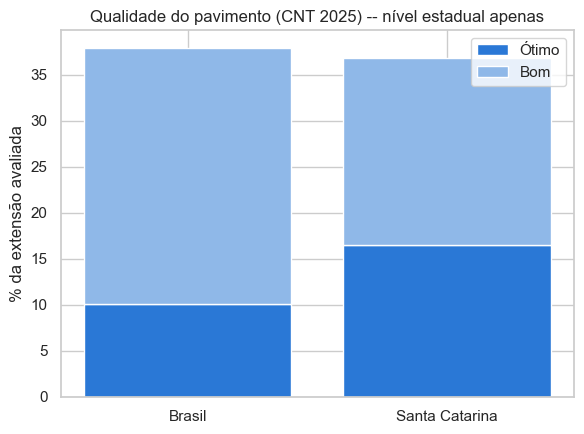

In [11]:
print("\n" + "=" * 70)
print("6 - QUALIDADE DO PAVIMENTO (CNT 2025) -- NÍVEL ESTADUAL")
print("=" * 70)

import pypdf

reader = pypdf.PdfReader(DADOS_DIR / "cnt_pesquisa_rodovias_2025.pdf")
texto_brasil = reader.pages[0].extract_text()
texto_sc = reader.pages[26].extract_text()


def extrair_estado_geral(texto):
    otimo = re.search(r"(\d+,\d+)%[^%]*?timo", texto)
    bom = re.search(r"(\d+,\d+)%\s*Bom", texto)
    return otimo.group(1) if otimo else None, bom.group(1) if bom else None


otimo_br, bom_br = extrair_estado_geral(texto_brasil)
otimo_sc, bom_sc = extrair_estado_geral(texto_sc)
print(f"Brasil 2025: {otimo_br}% ótimo, {bom_br}% bom (ótimo+bom)")
print(f"Santa Catarina 2025: {otimo_sc}% ótimo, {bom_sc}% bom (ótimo+bom)")
print("Aviso: síntese CNT é por ESTADO, não por trecho -- não permite isolar o pavimento")
print("especificamente no corredor Garuvá-Palhoça. Usado só como teto/contexto.")

fig, ax = plt.subplots(figsize=(6, 4.5))
labels = ["Brasil", "Santa Catarina"]
otimo_vals = [float(otimo_br.replace(",", ".")), float(otimo_sc.replace(",", "."))]
bom_vals = [float(bom_br.replace(",", ".")), float(bom_sc.replace(",", "."))]
x = np.arange(len(labels))
ax.bar(x, otimo_vals, color=COR_BASE, label="Ótimo")
ax.bar(x, bom_vals, bottom=otimo_vals, color="#8fb8e8", label="Bom")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("% da extensão avaliada")
ax.set_title("Qualidade do pavimento (CNT 2025) -- nível estadual apenas")
ax.legend()
plt.tight_layout()
plt.savefig(FIGS_DIR / "fig5_pavimento_cnt.png", dpi=150)
plt.show()

## 7 - Síntese

Recalculado a partir da janela 2022-2025 com comparativos de mesmo ano de início/fim. A leitura
muda em um ponto importante em relação à versão anterior: com frota e acidentes comparados na
**mesma janela (2022→2025)**, os acidentes no corredor **cresceram, não caíram** -- o comparativo
antigo (frota 2020→2025 vs acidentes 2024→2025) escondia isso ao só sobrepor a ponta final das
duas séries.

In [12]:
print("=" * 70)
print("SÍNTESE -- JANELA 2022-2025, COMPARATIVOS DE MESMO ANO DE INÍCIO/FIM")
print("=" * 70)
print(f"1. Corredor concentra {len(corredor)/len(br101_sc)*100:.1f}% dos acidentes da BR-101/SC ({len(corredor):,} de {len(br101_sc):,}), estável nos {N_ANOS} anos.")
print(f"2. Acidentes no corredor: {corredor_por_ano[ANO_INICIO]:,} ({ANO_INICIO}) -> {corredor_por_ano[ANO_FIM]:,} ({ANO_FIM}), {crescimento_acid:+.1f}%.")
print(f"3. Frota no corredor: {frota_inicio_total:,.0f} (Dez/{ANO_INICIO}) -> {frota_fim_total:,.0f} (Dez/{ANO_FIM}), {crescimento_frota:+.1f}%.")
print(f"   -> Nesta janela pareada, acidentes acompanham a frota de perto (diferença de {abs(crescimento_frota-crescimento_acid):.1f} p.p.),")
print("      ao contrário do comparativo anterior (janelas diferentes), que sugeria que acidentes não acompanhavam o crescimento da frota.")
print(f"4. VMDa 2022 x densidade de acidentes {ANO_INICIO}-{ANO_FIM}: correlação fraca (r = {corr_vmd_acid:.2f}) -- volume agregado por trecho não")
print("   explica sozinho onde os acidentes se concentram.")
print(f"5. {pct_pico_geral:.1f}% dos acidentes ocorrem em horário de pico (7-8h/17-19h, 20,8% do dia) -- proxy de pendularidade, não só turismo.")
print(f"6. {pct_caminhao:.1f}% dos veículos envolvidos em acidentes ({ANO_INICIO}-{ANO_FIM}) são caminhão/reboque, estável ano a ano.")
print("7. Pavimento SC (CNT 2025) está na média nacional -- não desponta como fator concorrente.")
print()
print("Limitações que seguem de pé: correlação fraca volume x acidentes por trecho; VMD sem ponto")
print("posterior a 2022 para medir crescimento de tráfego dentro da janela; pendularidade/carga")
print("portuária seguem apoiadas em proxies, não em série primária (ver readme_fontes.md).")

SÍNTESE -- JANELA 2022-2025, COMPARATIVOS DE MESMO ANO DE INÍCIO/FIM
1. Corredor concentra 77.8% dos acidentes da BR-101/SC (12,947 de 16,634), estável nos 4 anos.
2. Acidentes no corredor: 3,016 (2022) -> 3,352 (2025), +11.1%.
3. Frota no corredor: 1,910,799 (Dez/2022) -> 2,191,311 (Dez/2025), +14.7%.
   -> Nesta janela pareada, acidentes acompanham a frota de perto (diferença de 3.5 p.p.),
      ao contrário do comparativo anterior (janelas diferentes), que sugeria que acidentes não acompanhavam o crescimento da frota.
4. VMDa 2022 x densidade de acidentes 2022-2025: correlação fraca (r = 0.22) -- volume agregado por trecho não
   explica sozinho onde os acidentes se concentram.
5. 33.1% dos acidentes ocorrem em horário de pico (7-8h/17-19h, 20,8% do dia) -- proxy de pendularidade, não só turismo.
6. 14.7% dos veículos envolvidos em acidentes (2022-2025) são caminhão/reboque, estável ano a ano.
7. Pavimento SC (CNT 2025) está na média nacional -- não desponta como fator concorrente.
